# Optimal trade execution on real data

We evaluate one fixed RL setup across several folds.

We start by importing the libraries used in the notebook.

In [48]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict, Counter
from itertools import combinations
from typing import Dict, Tuple, List, Optional

We define one fixed configuration for training and testing.

In [49]:

N_STOCKS = 3
N_DAYS = 5
ALL_DAYS = list(range(N_DAYS))

OUTER_TEST_SIZE = 1
MAX_OUTER_FOLDS = None

H_SEC = 120
T_STEPS = 8
DT = H_SEC / T_STEPS

V_TOTAL = 100
I_LEVELS = 10
TICK_SIZE = 0.01

N_IMB_BINS = 3
N_RET_BINS = 3

MIN_COUNT_EXACT = 3
MIN_COUNT_STOCK = 10
MIN_COUNT_GLOBAL = 25

ACTION_SPECS = {
    "WAIT":    {"frac": 0.00, "type": "WAIT"},
    "MO_25":   {"frac": 0.25, "type": "MO"},
    "MO_50":   {"frac": 0.50, "type": "MO"},
    "MO_100":  {"frac": 1.00, "type": "MO"},
    "ASK_25":  {"frac": 0.25, "type": "ASK"},
    "ASK_50":  {"frac": 0.50, "type": "ASK"},
    "ASK_100": {"frac": 1.00, "type": "ASK"},
}
ACTIONS = list(ACTION_SPECS.keys())

STATE_LABEL = "spread + imbalance + return"
STATE_FEATURES = ["spread_disc", "imb_disc", "ret_disc"]

We load the raw order book updates for all stocks and days.

In [50]:

def load_updates(n_stocks=N_STOCKS, n_days=N_DAYS):
    dfs = []
    for stock in range(n_stocks):
        for day in range(n_days):
            path = f"Data/stock{stock}_day{day}_updates.csv.gz"
            df = pd.read_csv(path, compression="gzip")
            df["stock"] = stock
            df["day"] = day
            dfs.append(df)

    updates = pd.concat(dfs, ignore_index=True)

    ts_num = pd.to_numeric(updates["ts"], errors="coerce")

    if ts_num.notna().all():
        updates["ts_raw"] = ts_num.astype("int64")

        raw_spans = (
            updates.groupby(["stock", "day"])["ts_raw"]
                   .agg(lambda x: float(x.max() - x.min()))
        )
        median_raw_span = float(raw_spans.median())

        if median_raw_span >= 1e13:
            inferred_unit = "ns"
            scale_to_seconds = 1e9
        elif median_raw_span >= 1e10:
            inferred_unit = "us"
            scale_to_seconds = 1e6
        elif median_raw_span >= 1e7:
            inferred_unit = "ms"
            scale_to_seconds = 1e3
        else:
            inferred_unit = "s"
            scale_to_seconds = 1.0

        updates = updates.sort_values(["stock", "day", "ts_raw"]).reset_index(drop=True)
        updates["ts_sec"] = (
            updates.groupby(["stock", "day"])["ts_raw"]
                   .transform(lambda x: (x - x.min()) / scale_to_seconds)
                   .astype(float)
        )

        updates.attrs["ts_mode"] = f"numeric/{inferred_unit}"
        updates.attrs["ts_scale_to_seconds"] = scale_to_seconds
        updates.attrs["median_raw_span"] = median_raw_span

    else:
        updates["ts"] = pd.to_datetime(updates["ts"], errors="coerce")
        updates = updates.dropna(subset=["ts"]).sort_values(["stock", "day", "ts"]).reset_index(drop=True)
        updates["ts_sec"] = (
            updates.groupby(["stock", "day"])["ts"]
                   .transform(lambda x: (x - x.min()).dt.total_seconds())
                   .astype(float)
        )

        updates.attrs["ts_mode"] = "datetime"
        updates.attrs["ts_scale_to_seconds"] = 1.0

    return updates


updates = load_updates()

print(f"Rows: {len(updates):,}")
print(f"Timestamp parsing mode: {updates.attrs.get('ts_mode', 'unknown')}")
if "median_raw_span" in updates.attrs:
    print(f"Median raw span across (stock, day): {updates.attrs['median_raw_span']:.0f}")

display(updates.groupby(["stock", "day"]).size().unstack(fill_value=0))

Rows: 4,705,051
Timestamp parsing mode: datetime


day,0,1,2,3,4
stock,,,,,
0,226217,338090,334977,468433,550083
1,73947,128253,139805,214988,201558
2,212731,365027,371879,491762,587301


We build the L1 book and create causal features from past information only.

In [51]:

def prepare_book(updates: pd.DataFrame) -> pd.DataFrame:
    updates = updates.sort_values(["stock", "day", "ts_sec"]).copy()

    for col in ["bp", "ap", "bq", "aq"]:
        updates[f"{col}_f"] = updates.groupby(["stock", "day"])[col].ffill()

    book = updates.dropna(subset=["bp_f", "ap_f"]).copy()

    book["bq_f"] = book["bq_f"].fillna(0.0)
    book["aq_f"] = book["aq_f"].fillna(0.0)

    book = book[(book["ap_f"] > book["bp_f"]) & (book["bq_f"] >= 0) & (book["aq_f"] >= 0)].copy()

    book["mid"] = (book["bp_f"] + book["ap_f"]) / 2.0
    book["spread"] = book["ap_f"] - book["bp_f"]
    book["spread_ticks"] = np.maximum(1, np.round(book["spread"] / TICK_SIZE)).astype(int)

    denom = book["bq_f"] + book["aq_f"]
    book["imbalance"] = np.where(denom > 0, (book["bq_f"] - book["aq_f"]) / (denom + 1e-9), 0.0)
    book["event_type"] = book["type"].astype(str)

    return book.reset_index(drop=True)


def add_causal_features(ob: pd.DataFrame) -> pd.DataFrame:
    ob = ob.sort_values(["stock", "day", "ts_sec"]).copy()
    g = ob.groupby(["stock", "day"], group_keys=False)

    ob["mid_ret_1"] = g["mid"].diff().fillna(0.0)
    abs_ret = g["mid"].diff().abs().fillna(0.0)
    ob["abs_ret_30obs"] = (
        abs_ret.groupby([ob["stock"], ob["day"]])
               .transform(lambda x: x.rolling(window=30, min_periods=1).mean())
               .fillna(0.0)
    )
    ob["spread_disc"] = np.clip(ob["spread_ticks"], 1, 4) - 1
    return ob


ob_base = prepare_book(updates)
ob_base = add_causal_features(ob_base)

print(f"Rows retained for decision snapshots: {len(ob_base):,}")

coverage_df = (
    ob_base.groupby(["stock", "day"])
           .agg(n_rows=("ts_sec", "size"), t_start=("ts_sec", "min"), t_end=("ts_sec", "max"))
)
coverage_df["span_s"] = coverage_df["t_end"] - coverage_df["t_start"]

display(coverage_df[["n_rows", "span_s"]].unstack(fill_value=0))

Rows retained for decision snapshots: 4,702,118


n_rows                                        span_s                \
day         0       1       2       3       4             0             1   
stock                                                                       
0      226128  337946  334854  468227  549738  30572.597315  30583.157192   
1       73581  128020  139555  214976  201514  30574.477783  30582.030305   
2      212559  364764  371752  491409  587095  30584.548869  30570.844902   

                                                 
day               2             3             4  
stock                                            
0      30576.132278  30586.320706  30576.590997  
1      30586.326783  30599.070250  30588.854969  
2      30589.326382  30574.219369  30580.192321

We fit the discretization on training days and apply it to each fold.

In [52]:

def fit_quantile_bins(train_series: pd.Series, q: int = 3):
    s = train_series.dropna()
    if s.empty:
        return None
    bins = s.quantile(np.linspace(0, 1, q + 1)).values
    bins = np.unique(bins)
    if len(bins) < 2:
        return None
    bins[0] = -np.inf
    bins[-1] = np.inf
    return bins


def apply_bins(series: pd.Series, bins):
    if bins is None:
        return pd.Series(np.zeros(len(series), dtype=int), index=series.index)
    out = pd.cut(series, bins=bins, labels=False, include_lowest=True)
    return out.fillna(0).astype(int)


def discretize_features_by_train_days(ob: pd.DataFrame,
                                      train_days: List[int],
                                      n_imb_bins: int = N_IMB_BINS,
                                      n_ret_bins: int = N_RET_BINS) -> Tuple[pd.DataFrame, Dict]:
    ob = ob.copy()
    ob["imb_disc"] = -1
    ob["ret_disc"] = -1

    bins_by_stock = {}

    for stk in sorted(ob["stock"].unique()):
        m_train = (ob["stock"] == stk) & (ob["day"].isin(train_days))
        imb_bins = fit_quantile_bins(ob.loc[m_train, "imbalance"], q=n_imb_bins)
        ret_bins = fit_quantile_bins(ob.loc[m_train, "mid_ret_1"], q=n_ret_bins)

        bins_by_stock[int(stk)] = {
            "imb_bins": imb_bins,
            "ret_bins": ret_bins,
        }

        m_stock = ob["stock"] == stk
        ob.loc[m_stock, "imb_disc"] = apply_bins(ob.loc[m_stock, "imbalance"], imb_bins)
        ob.loc[m_stock, "ret_disc"] = apply_bins(ob.loc[m_stock, "mid_ret_1"], ret_bins)

    for col in ["spread_disc", "imb_disc", "ret_disc"]:
        ob[col] = ob[col].astype(int)

    return ob, bins_by_stock

We convert each day into trading episodes on a fixed decision grid.

In [53]:

def build_episodes(ob_data: pd.DataFrame, days: List[int], H: float = H_SEC, T: int = T_STEPS):
    episodes = []

    for (stk, day), grp in ob_data[ob_data["day"].isin(days)].groupby(["stock", "day"]):
        grp = grp.sort_values("ts_sec").reset_index(drop=True)
        ts_vals = grp["ts_sec"].to_numpy(dtype=float)

        if len(ts_vals) < (T + 1):
            continue

        ts_start = float(ts_vals[0])
        ts_end = float(ts_vals[-1])
        span = ts_end - ts_start

        if span < H:
            continue

        n_windows = int(np.floor(span / H))

        for w in range(n_windows):
            t0 = ts_start + w * H

            snapshots = []
            valid = True

            for step in range(T + 1):
                t_target = t0 + step * (H / T)
                idx = np.searchsorted(ts_vals, t_target, side="right") - 1
                if idx < 0 or idx >= len(grp):
                    valid = False
                    break
                snapshots.append(grp.iloc[idx])

            if valid and len(snapshots) == T + 1:
                snap_times = [float(s["ts_sec"]) for s in snapshots]
                if len(set(snap_times)) >= 2:
                    episodes.append({
                        "stock": int(stk),
                        "day": int(day),
                        "t0_sec": float(t0),
                        "snapshots": snapshots,
                    })

    return episodes

We define the state representation used by the RL agent.

In [54]:

def inventory_level(remaining: float, total: float = V_TOTAL, n_levels: int = I_LEVELS) -> int:
    ratio = remaining / total
    return int(np.clip(np.round(ratio * n_levels), 0, n_levels))


def inventory_from_level(inv_level: int, total: float = V_TOTAL, n_levels: int = I_LEVELS) -> int:
    return int(np.round(inv_level / n_levels * total))


def state_key(stock: int, inv_level: int, snapshot: pd.Series, state_features: List[str]) -> Tuple[int, ...]:
    market = tuple(int(snapshot[f]) for f in state_features)
    return (int(stock), int(inv_level), *market)

We simulate how each child order is executed between two snapshots.

In [55]:

def action_to_child_order(action_id: str, inventory: int) -> Tuple[int, str]:
    spec = ACTION_SPECS[action_id]
    order_type = spec["type"]

    if order_type == "WAIT" or inventory <= 0:
        return 0, "WAIT"

    qty = int(np.ceil(spec["frac"] * inventory))
    qty = max(1, qty)
    qty = min(qty, int(inventory))
    return qty, order_type


def simulate_sell_child_order(snapshot_start: pd.Series,
                              snapshot_end: pd.Series,
                              inventory: int,
                              child_qty: int,
                              order_type: str) -> Tuple[int, float, int]:
    child_qty = int(max(0, min(child_qty, inventory)))
    if inventory <= 0 or child_qty <= 0 or order_type == "WAIT":
        return 0, np.nan, inventory

    bp0 = float(snapshot_start["bp_f"])
    ap0 = float(snapshot_start["ap_f"])
    bp1 = float(snapshot_end["bp_f"])
    ap1 = float(snapshot_end["ap_f"])

    if order_type == "MO":
        exec_qty = child_qty
        exec_price = bp0
        return exec_qty, exec_price, inventory - exec_qty

    if order_type == "ASK":
        limit_price = ap0
        ask_level_cleared = (bp1 >= limit_price - 1e-12) or (ap1 > limit_price + 1e-12)
        if ask_level_cleared:
            exec_qty = child_qty
            exec_price = limit_price
            return exec_qty, exec_price, inventory - exec_qty
        return 0, np.nan, inventory

    raise ValueError(f"Unknown order_type={order_type}")


def step_cost_cash(snapshot_start: pd.Series,
                   snapshot_end: pd.Series,
                   exec_qty: int,
                   exec_price: float,
                   inv_after: int) -> float:
    mid_t = float(snapshot_start["mid"])
    mid_next = float(snapshot_end["mid"])
    exec_cost = 0.0 if exec_qty <= 0 else exec_qty * (mid_t - exec_price)
    hold_cost = inv_after * (mid_t - mid_next)
    return exec_cost + hold_cost


def terminal_market_cost_cash(snapshot_last: pd.Series, inventory: int) -> float:
    if inventory <= 0:
        return 0.0
    mid = float(snapshot_last["mid"])
    bid = float(snapshot_last["bp_f"])
    return inventory * (mid - bid)


def cost_cash_to_bps(total_cost_cash: float, arrival_mid: float, total_qty: int = V_TOTAL) -> float:
    notional = total_qty * arrival_mid
    return (total_cost_cash / notional) * 10_000.0

We store value and Q estimates with exact, stock, and global backoff levels.

In [56]:

def _state_to_stock_key(state: Tuple[int, ...]):
    stock = state[0]
    inv_level = state[1]
    return (stock, inv_level)


def _state_to_global_key(state: Tuple[int, ...]):
    inv_level = state[1]
    return (inv_level,)


def make_stat_store():
    return {
        "exact_sum": defaultdict(float),
        "exact_count": defaultdict(int),
        "stock_sum": defaultdict(float),
        "stock_count": defaultdict(int),
        "global_sum": defaultdict(float),
        "global_count": defaultdict(int),
    }


def add_stat(store, state: Tuple[int, ...], value: float):
    store["exact_sum"][state] += value
    store["exact_count"][state] += 1

    stock_key = _state_to_stock_key(state)
    store["stock_sum"][stock_key] += value
    store["stock_count"][stock_key] += 1

    global_key = _state_to_global_key(state)
    store["global_sum"][global_key] += value
    store["global_count"][global_key] += 1


def lookup_stat_mean(store,
                     state: Tuple[int, ...],
                     min_exact: int = MIN_COUNT_EXACT,
                     min_stock: int = MIN_COUNT_STOCK,
                     min_global: int = MIN_COUNT_GLOBAL) -> Tuple[Optional[float], str]:
    if store["exact_count"][state] >= min_exact:
        return store["exact_sum"][state] / store["exact_count"][state], "exact"

    stock_key = _state_to_stock_key(state)
    if store["stock_count"][stock_key] >= min_stock:
        return store["stock_sum"][stock_key] / store["stock_count"][stock_key], "stock"

    global_key = _state_to_global_key(state)
    if store["global_count"][global_key] >= min_global:
        return store["global_sum"][global_key] / store["global_count"][global_key], "global"

    return None, "fallback"


def make_q_store():
    return {
        "exact_sum": defaultdict(float),
        "exact_count": defaultdict(int),
        "stock_sum": defaultdict(float),
        "stock_count": defaultdict(int),
        "global_sum": defaultdict(float),
        "global_count": defaultdict(int),
    }


def add_q(store, state: Tuple[int, ...], action: str, q_value: float):
    exact_key = (state, action)
    store["exact_sum"][exact_key] += q_value
    store["exact_count"][exact_key] += 1

    stock_key = (_state_to_stock_key(state), action)
    store["stock_sum"][stock_key] += q_value
    store["stock_count"][stock_key] += 1

    global_key = (_state_to_global_key(state), action)
    store["global_sum"][global_key] += q_value
    store["global_count"][global_key] += 1


def lookup_q_mean(store,
                  state: Tuple[int, ...],
                  action: str,
                  min_exact: int = MIN_COUNT_EXACT,
                  min_stock: int = MIN_COUNT_STOCK,
                  min_global: int = MIN_COUNT_GLOBAL) -> Tuple[Optional[float], str]:
    exact_key = (state, action)
    if store["exact_count"][exact_key] >= min_exact:
        return store["exact_sum"][exact_key] / store["exact_count"][exact_key], "exact"

    stock_key = (_state_to_stock_key(state), action)
    if store["stock_count"][stock_key] >= min_stock:
        return store["stock_sum"][stock_key] / store["stock_count"][stock_key], "stock"

    global_key = (_state_to_global_key(state), action)
    if store["global_count"][global_key] >= min_global:
        return store["global_sum"][global_key] / store["global_count"][global_key], "global"

    return None, "fallback"

We train the policy with backward dynamic programming on the training episodes.

In [57]:

def train_backward_dp(episodes_train: List[dict],
                      state_features: List[str],
                      actions: List[str] = ACTIONS):
    V_tables = {}
    Q_tables = {}
    backoff_counters = Counter()

    V0 = make_stat_store()
    for ep in episodes_train:
        snap_last = ep["snapshots"][-1]
        stk = ep["stock"]

        for inv_level in range(I_LEVELS + 1):
            inv = inventory_from_level(inv_level)
            state = state_key(stk, inv_level, snap_last, state_features)
            add_stat(V0, state, terminal_market_cost_cash(snap_last, inv))

    V_tables[0] = V0

    for t_rem in range(1, T_STEPS + 1):
        step_idx = T_STEPS - t_rem
        Q_t = make_q_store()

        for ep in episodes_train:
            stk = ep["stock"]
            snaps = ep["snapshots"]
            snap_cur = snaps[step_idx]
            snap_next = snaps[step_idx + 1]

            for inv_level in range(I_LEVELS + 1):
                inventory = inventory_from_level(inv_level)
                state = state_key(stk, inv_level, snap_cur, state_features)

                for action in actions:
                    child_qty, order_type = action_to_child_order(action, inventory)
                    exec_qty, exec_price, inv_after = simulate_sell_child_order(
                        snap_cur, snap_next, inventory, child_qty, order_type
                    )

                    immediate_cost = step_cost_cash(
                        snap_cur, snap_next, exec_qty, exec_price, inv_after
                    )

                    next_inv_level = inventory_level(inv_after)
                    next_state = state_key(stk, next_inv_level, snap_next, state_features)

                    future_cost, source = lookup_stat_mean(V_tables[t_rem - 1], next_state)
                    backoff_counters[(t_rem - 1, "V", source)] += 1
                    if future_cost is None:
                        future_cost = terminal_market_cost_cash(snap_next, inv_after)

                    add_q(Q_t, state, action, immediate_cost + future_cost)

        Q_tables[t_rem] = Q_t

        V_t = make_stat_store()
        seen_states = {state for (state, action) in Q_t["exact_count"].keys()}

        for state in seen_states:
            q_candidates = []
            for action in actions:
                q_mean, source = lookup_q_mean(Q_t, state, action)
                backoff_counters[(t_rem, "Q", source)] += 1
                if q_mean is not None:
                    q_candidates.append(q_mean)

            if q_candidates:
                add_stat(V_t, state, min(q_candidates))

        V_tables[t_rem] = V_t

    return V_tables, Q_tables, backoff_counters

We define the RL policy and a few simple baselines for comparison.

In [58]:

def choose_rl_action(stock: int,
                     t_rem: int,
                     inventory: int,
                     snapshot: pd.Series,
                     q_tables,
                     state_features: List[str]) -> Tuple[str, str]:
    inv_level = inventory_level(inventory)
    state = state_key(stock, inv_level, snapshot, state_features)

    q_values = {}
    sources = {}
    for action in ACTIONS:
        q_val, source = lookup_q_mean(q_tables[t_rem], state, action)
        q_values[action] = q_val
        sources[action] = source

    valid = {a: v for a, v in q_values.items() if v is not None}
    if valid:
        best = min(valid, key=valid.get)
        return best, sources[best]

    return ("MO_25" if t_rem > 1 else "MO_100"), "fallback"


def make_rl_policy(q_tables, state_features: List[str]):
    def _policy(stock, t_rem, inventory, snapshot, step_idx):
        action_id, _ = choose_rl_action(stock, t_rem, inventory, snapshot, q_tables, state_features)
        return action_to_child_order(action_id, inventory)
    return _policy


def immediate_market_policy(stock, t_rem, inventory, snapshot, step_idx):
    if step_idx == 0 and inventory > 0:
        return inventory, "MO"
    return 0, "WAIT"


def twap_market_policy(stock, t_rem, inventory, snapshot, step_idx):
    if inventory <= 0:
        return 0, "WAIT"
    target_remaining_next = int(np.round(V_TOTAL * (t_rem - 1) / T_STEPS))
    child_qty = max(0, inventory - target_remaining_next)
    return child_qty, "MO"


def twap_passive_ask_policy(stock, t_rem, inventory, snapshot, step_idx):
    if inventory <= 0:
        return 0, "WAIT"
    target_remaining_next = int(np.round(V_TOTAL * (t_rem - 1) / T_STEPS))
    child_qty = max(0, inventory - target_remaining_next)
    return child_qty, "ASK"


def wait_then_sweep_policy(stock, t_rem, inventory, snapshot, step_idx):
    if inventory <= 0:
        return 0, "WAIT"
    if t_rem <= 2:
        return inventory, "MO"
    return 0, "WAIT"


def rollout_episode(ep: dict, policy_fn) -> dict:
    snaps = ep["snapshots"]
    stock = ep["stock"]

    inventory = int(V_TOTAL)
    total_cost_cash = 0.0
    history = []

    for step_idx in range(T_STEPS):
        if inventory <= 0:
            break

        snap_cur = snaps[step_idx]
        snap_next = snaps[step_idx + 1]
        t_rem = T_STEPS - step_idx

        child_qty, order_type = policy_fn(stock, t_rem, inventory, snap_cur, step_idx)
        exec_qty, exec_price, inv_after = simulate_sell_child_order(
            snap_cur, snap_next, inventory, child_qty, order_type
        )

        step_cost = step_cost_cash(snap_cur, snap_next, exec_qty, exec_price, inv_after)
        total_cost_cash += step_cost

        history.append({
            "step": step_idx,
            "t_rem": t_rem,
            "inventory_before": inventory,
            "child_qty": child_qty,
            "order_type": order_type,
            "exec_qty": exec_qty,
            "exec_price": exec_price,
            "inventory_after": inv_after,
            "step_cost_cash": step_cost,
        })

        inventory = inv_after

    if inventory > 0:
        total_cost_cash += terminal_market_cost_cash(snaps[-1], inventory)

    arrival_mid = float(snaps[0]["mid"])
    total_cost_bps = cost_cash_to_bps(total_cost_cash, arrival_mid, total_qty=V_TOTAL)

    return {
        "stock": stock,
        "day": ep["day"],
        "cost_cash": total_cost_cash,
        "cost_bps": total_cost_bps,
        "history": history,
    }


def evaluate_policy(episodes: List[dict], policy_fn, label: str, verbose: bool = True):
    if len(episodes) == 0:
        if verbose:
            print(f"{label:28s} -> mean =     nan bps | std =     nan | N = 0")
        return {
            "label": label,
            "mean_bps": np.nan,
            "std_bps": np.nan,
            "median_bps": np.nan,
            "n_episodes": 0,
            "costs_bps": np.array([], dtype=float),
            "outputs": [],
        }

    outputs = [rollout_episode(ep, policy_fn) for ep in episodes]
    costs = np.array([o["cost_bps"] for o in outputs], dtype=float)

    if verbose:
        print(f"{label:28s} -> mean = {costs.mean():7.3f} bps | std = {costs.std():7.3f} | N = {len(costs)}")

    return {
        "label": label,
        "mean_bps": float(costs.mean()),
        "std_bps": float(costs.std()),
        "median_bps": float(np.median(costs)),
        "n_episodes": int(len(costs)),
        "costs_bps": costs,
        "outputs": outputs,
    }

We prepare the outer folds used to evaluate the same model on different test days.

In [59]:

def generate_day_folds(days: List[int], test_size: int = 1, max_folds: Optional[int] = None) -> List[Tuple[int, ...]]:
    folds = list(combinations(sorted(days), test_size))
    if max_folds is not None:
        folds = folds[:max_folds]
    return [tuple(int(x) for x in fold) for fold in folds]

We train the fixed RL model on each fold and test it on the held out day.

In [60]:

outer_test_folds = generate_day_folds(
    days=ALL_DAYS,
    test_size=OUTER_TEST_SIZE,
    max_folds=MAX_OUTER_FOLDS,
)

print(f"Fixed state configuration: {STATE_LABEL}")
print(f"Outer test folds: {outer_test_folds}")

outer_fold_results = []
outer_test_strategy_rows = []
outer_test_episode_rows = []

for outer_idx, outer_test_days in enumerate(outer_test_folds, start=1):
    outer_test_days = list(outer_test_days)
    outer_train_days = [d for d in ALL_DAYS if d not in outer_test_days]

    print()
    print(f"Fold {outer_idx}/{len(outer_test_folds)}")
    print(f"Train days: {outer_train_days}")
    print(f"Test days: {outer_test_days}")

    ob_fold, _ = discretize_features_by_train_days(ob_base, train_days=outer_train_days)
    episodes_train = build_episodes(ob_fold, days=outer_train_days)
    episodes_test = build_episodes(ob_fold, days=outer_test_days)

    if len(episodes_train) == 0:
        print("No training episodes available on this fold.")
        outer_fold_results.append({
            "outer_fold": outer_idx,
            "train_days": tuple(outer_train_days),
            "test_days": tuple(outer_test_days),
            "train_episodes": 0,
            "test_episodes": len(episodes_test),
            "rl_mean_bps": np.nan,
            "rl_std_bps": np.nan,
            "rl_median_bps": np.nan,
        })
        continue

    V_tables, Q_tables, backoff = train_backward_dp(
        episodes_train=episodes_train,
        state_features=STATE_FEATURES,
        actions=ACTIONS,
    )

    rl_policy = make_rl_policy(Q_tables, STATE_FEATURES)

    res_rl = evaluate_policy(episodes_test, rl_policy, "RL fixed config", verbose=True)
    res_immediate = evaluate_policy(episodes_test, immediate_market_policy, "Immediate Market", verbose=True)
    res_twap_mo = evaluate_policy(episodes_test, twap_market_policy, "TWAP MO", verbose=True)
    res_twap_ask = evaluate_policy(episodes_test, twap_passive_ask_policy, "TWAP Passive Ask", verbose=True)
    res_wait_sweep = evaluate_policy(episodes_test, wait_then_sweep_policy, "Wait then Sweep", verbose=True)

    outer_fold_results.append({
        "outer_fold": outer_idx,
        "train_days": tuple(outer_train_days),
        "test_days": tuple(outer_test_days),
        "train_episodes": len(episodes_train),
        "test_episodes": len(episodes_test),
        "rl_mean_bps": res_rl["mean_bps"],
        "rl_std_bps": res_rl["std_bps"],
        "rl_median_bps": res_rl["median_bps"],
    })

    for strat_res in [res_rl, res_immediate, res_twap_mo, res_twap_ask, res_wait_sweep]:
        outer_test_strategy_rows.append({
            "outer_fold": outer_idx,
            "test_days": tuple(outer_test_days),
            "strategy": strat_res["label"],
            "mean_bps": strat_res["mean_bps"],
            "std_bps": strat_res["std_bps"],
            "median_bps": strat_res["median_bps"],
            "n_episodes": strat_res["n_episodes"],
        })

        for cost in strat_res["costs_bps"]:
            outer_test_episode_rows.append({
                "outer_fold": outer_idx,
                "test_days": tuple(outer_test_days),
                "strategy": strat_res["label"],
                "cost_bps": float(cost),
            })

Fixed state configuration: spread + imbalance + return
Outer test folds: [(0,), (1,), (2,), (3,), (4,)]

Fold 1/5
Train days: [1, 2, 3, 4]
Test days: [0]
RL fixed config              -> mean =   0.988 bps | std =   6.750 | N = 762
Immediate Market             -> mean =   1.591 bps | std =   1.115 | N = 762
TWAP MO                      -> mean =   1.482 bps | std =   4.097 | N = 762
TWAP Passive Ask             -> mean =   1.183 bps | std =   6.051 | N = 762
Wait then Sweep              -> mean =   1.378 bps | std =   6.707 | N = 762

Fold 2/5
Train days: [0, 2, 3, 4]
Test days: [1]
RL fixed config              -> mean =   1.336 bps | std =   8.374 | N = 762
Immediate Market             -> mean =   1.752 bps | std =   1.474 | N = 762
TWAP MO                      -> mean =   1.696 bps | std =   4.916 | N = 762
TWAP Passive Ask             -> mean =   1.800 bps | std =   7.151 | N = 762
Wait then Sweep              -> mean =   1.758 bps | std =   8.178 | N = 762

Fold 3/5
Train days: [0, 

We summarize the RL performance obtained on each fold.

In [61]:

outer_folds_df = pd.DataFrame(outer_fold_results)
display(outer_folds_df.round(4))

,outer_fold,train_days,test_days,train_episodes,test_episodes,rl_mean_bps,rl_std_bps,rl_median_bps
0,1,"(1, 2, 3, 4)","(0,)",3048,762,0.9883,6.7504,0.9035
1,2,"(0, 2, 3, 4)","(1,)",3048,762,1.3358,8.3739,0.9502
2,3,"(0, 1, 3, 4)","(2,)",3048,762,0.8885,8.3634,0.8898
3,4,"(0, 1, 2, 4)","(3,)",3048,762,1.6320,11.0895,0.9682
4,5,"(0, 1, 2, 3)","(4,)",3048,762,1.8797,10.3116,1.0046


We aggregate the test results across folds for all strategies.

In [62]:

outer_test_results_df = pd.DataFrame(outer_test_strategy_rows)
outer_test_episode_df = pd.DataFrame(outer_test_episode_rows)

display(outer_test_results_df.round(4))

if not outer_test_results_df.empty:
    outer_agg_df = (
        outer_test_results_df.groupby("strategy", as_index=False)
                             .agg(
                                 mean_of_fold_means=("mean_bps", "mean"),
                                 std_of_fold_means=("mean_bps", "std"),
                                 median_of_fold_means=("mean_bps", "median"),
                                 total_test_episodes=("n_episodes", "sum"),
                                 n_outer_folds=("outer_fold", "nunique"),
                             )
                             .sort_values("mean_of_fold_means", na_position="last")
                             .reset_index(drop=True)
    )
    display(outer_agg_df.round(4))

,outer_fold,test_days,strategy,mean_bps,std_bps,median_bps,n_episodes
0,1,"(0,)",RL fixed config,0.9883,6.7504,0.9035,762
1,1,"(0,)",Immediate Market,1.5906,1.1154,0.9458,762
2,1,"(0,)",TWAP MO,1.4816,4.0972,1.3653,762
3,1,"(0,)",TWAP Passive Ask,1.1835,6.0514,0.7095,762
4,1,"(0,)",Wait then Sweep,1.3780,6.7073,0.9360,762
5,2,"(1,)",RL fixed config,1.3358,8.3739,0.9502,762
6,2,"(1,)",Immediate Market,1.7524,1.4738,1.8065,762
7,2,"(1,)",TWAP MO,1.6963,4.9157,1.6398,762
8,2,"(1,)",TWAP Passive Ask,1.8000,7.1510,0.9510,762
9,2,"(1,)",Wait then Sweep,1.7581,8.1782,0.9550,762


,strategy,mean_of_fold_means,std_of_fold_means,median_of_fold_means,total_test_episodes,n_outer_folds
0,RL fixed config,1.3449,0.4195,1.3358,3810,5
1,Wait then Sweep,1.7275,0.4497,1.7581,3810,5
2,Immediate Market,1.7417,0.1235,1.7524,3810,5
3,TWAP MO,1.7558,0.4138,1.6963,3810,5
4,TWAP Passive Ask,1.9209,0.7776,1.8000,3810,5


We visualize how the strategies behave across the different folds.

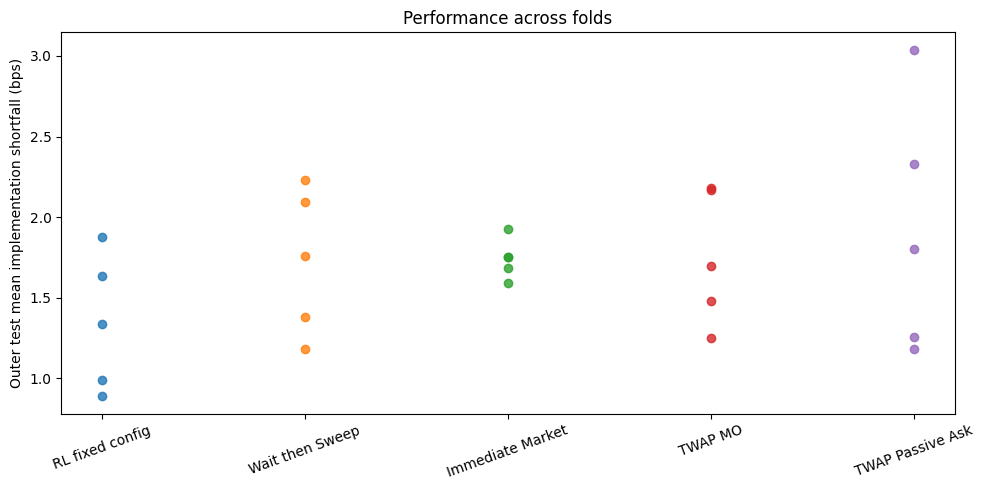

In [63]:

if not outer_test_results_df.empty:
    plt.figure(figsize=(10, 5))
    plot_df = outer_test_results_df.copy()
    order = (
        plot_df.groupby("strategy")["mean_bps"]
               .mean()
               .sort_values()
               .index.tolist()
    )

    for strategy in order:
        y = plot_df.loc[plot_df["strategy"] == strategy, "mean_bps"].to_numpy()
        x = np.full_like(y, fill_value=order.index(strategy), dtype=float)
        plt.scatter(x, y, alpha=0.8, label=strategy)

    plt.xticks(range(len(order)), order, rotation=20)
    plt.ylabel("Outer test mean implementation shortfall (bps)")
    plt.title("Performance across folds")
    plt.tight_layout()
    plt.show()

We compare the pooled RL results with the immediate market baseline.

Convention: diff = cost(Immediate Market) - cost(RL fixed config)
diff > 0 means RL is better
N pooled episodes       : 3810
Mean RL gain in bps     : 0.3968
Median RL gain in bps   : 0.0000
Pct RL better           : 46.96%
Bootstrap 95% CI        : [0.1031, 0.6929] bps
Paired t test p value   : 0.00399922
Wilcoxon p value        : 7.37872e-05


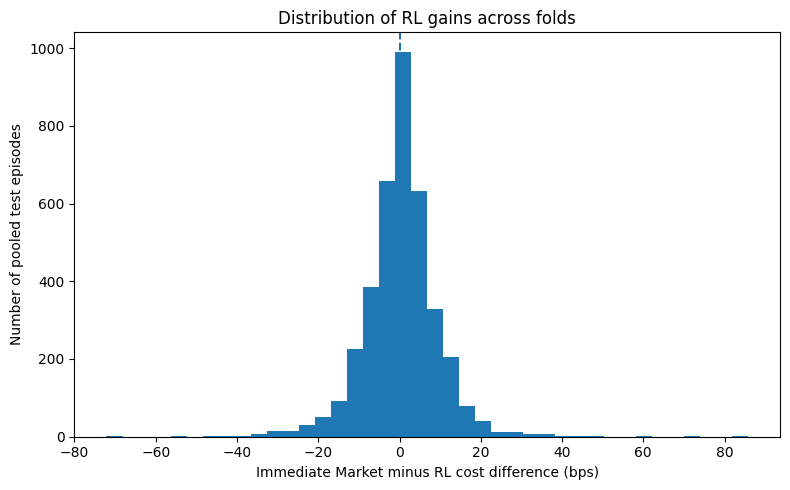

In [64]:

if not outer_test_episode_df.empty:
    rl_rows = outer_test_episode_df[outer_test_episode_df["strategy"] == "RL fixed config"].copy()
    baseline_rows = outer_test_episode_df[outer_test_episode_df["strategy"] == "Immediate Market"].copy()

    if len(rl_rows) == len(baseline_rows) and len(rl_rows) > 0:
        diff = baseline_rows["cost_bps"].to_numpy() - rl_rows["cost_bps"].to_numpy()

        print("Convention: diff = cost(Immediate Market) - cost(RL fixed config)")
        print("diff > 0 means RL is better")
        print(f"N pooled episodes       : {len(diff)}")
        print(f"Mean RL gain in bps     : {diff.mean():.4f}")
        print(f"Median RL gain in bps   : {np.median(diff):.4f}")
        print(f"Pct RL better           : {100*np.mean(diff > 0):.2f}%")

        rng = np.random.default_rng(123)
        n_boot = 10000
        boot_means = np.empty(n_boot, dtype=float)
        n = len(diff)

        for b in range(n_boot):
            idx = rng.integers(0, n, size=n)
            boot_means[b] = diff[idx].mean()

        ci_low, ci_high = np.quantile(boot_means, [0.025, 0.975])
        print(f"Bootstrap 95% CI        : [{ci_low:.4f}, {ci_high:.4f}] bps")

        try:
            from scipy import stats

            t_res = stats.ttest_rel(
                baseline_rows["cost_bps"].to_numpy(),
                rl_rows["cost_bps"].to_numpy(),
                alternative="greater",
            )
            print(f"Paired t test p value   : {t_res.pvalue:.6g}")

            try:
                w_res = stats.wilcoxon(
                    baseline_rows["cost_bps"].to_numpy(),
                    rl_rows["cost_bps"].to_numpy(),
                    alternative="greater",
                    zero_method="wilcox",
                )
                print(f"Wilcoxon p value        : {w_res.pvalue:.6g}")
            except Exception as e:
                print(f"Wilcoxon unavailable    : {e}")
        except Exception:
            print("scipy unavailable, so paired tests were not computed.")

        plt.figure(figsize=(8, 5))
        plt.hist(diff, bins=40)
        plt.axvline(0.0, linestyle="--")
        plt.xlabel("Immediate Market minus RL cost difference (bps)")
        plt.ylabel("Number of pooled test episodes")
        plt.title("Distribution of RL gains across folds")
        plt.tight_layout()
        plt.show()
    else:
        print("The pooled paired comparison is unavailable.")